<a href="https://colab.research.google.com/github/the-star-boy/Local-repo/blob/main/Z_score.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
df=pd.read_csv('placement.csv')

In [13]:
df.sample(4)

,cgpa,placement_exam_marks,placed
320,7.18,51.0,1
253,6.98,76.0,0
118,6.90,54.0,0
21,7.43,33.0,1


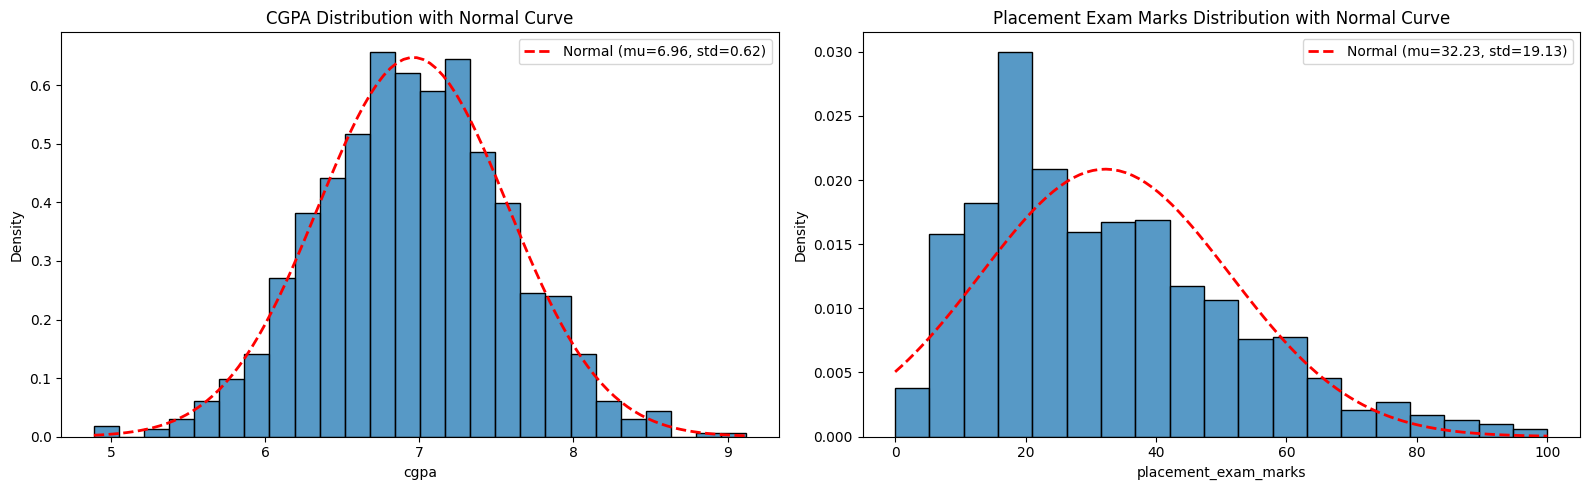

In [23]:
from scipy.stats import norm

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot for 'cgpa'
sns.histplot(df['cgpa'], ax=axes[0], stat='density', kde=False)
mu_cgpa, std_cgpa = df['cgpa'].mean(), df['cgpa'].std()
x_cgpa = np.linspace(df['cgpa'].min(), df['cgpa'].max(), 100)
p_cgpa = norm.pdf(x_cgpa, mu_cgpa, std_cgpa)
axes[0].plot(x_cgpa, p_cgpa, color='red', linestyle='dashed', linewidth=2, label=f'Normal (mu={mu_cgpa:.2f}, std={std_cgpa:.2f})')
axes[0].set_title('CGPA Distribution with Normal Curve')
axes[0].legend()

# Plot for 'placement_exam_marks'
sns.histplot(df['placement_exam_marks'], ax=axes[1], stat='density', kde=False)
mu_marks, std_marks = df['placement_exam_marks'].mean(), df['placement_exam_marks'].std()
x_marks = np.linspace(df['placement_exam_marks'].min(), df['placement_exam_marks'].max(), 100)
p_marks = norm.pdf(x_marks, mu_marks, std_marks)
axes[1].plot(x_marks, p_marks, color='red', linestyle='dashed', linewidth=2, label=f'Normal (mu={mu_marks:.2f}, std={std_marks:.2f})')
axes[1].set_title('Placement Exam Marks Distribution with Normal Curve')
axes[1].legend()

plt.tight_layout()
plt.show()

In [26]:
print("Mean val of cgpa",df['cgpa'].mean())
print("Std val of cgpa",df['cgpa'].std())
print("min val of cgpa",df['cgpa'].min())
print("max val of cgpa",df['cgpa'].max())
#

Mean val of cgpa 6.96124
Std val of cgpa 0.6158978751323894
min val of cgpa 4.89
max val of cgpa 9.12


In [29]:
#Finding the boundary values
print("highest allowed",df['cgpa'].mean()+3*df['cgpa'].std())
print("lowest allowed",df['cgpa'].mean()-3*df['cgpa'].std())

highest allowed 8.808933625397168
lowest allowed 5.113546374602832


In [32]:
#fINDING THE OUTLIERS
df[(df['cgpa']>8.80)|(df['cgpa']<5.11)]

,cgpa,placement_exam_marks,placed
485,4.92,44.0,1
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
999,4.90,10.0,1


# **TRIMMING**

In [35]:
new_df=df[(df['cgpa']<8.80) & (df['cgpa']>5.11)]
new_df

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
991,7.04,57.0,0
992,6.26,12.0,0
993,6.73,21.0,1
994,6.48,63.0,0


In [36]:
#approach 2(Calculating the z score)
df['cgpa_zscore']=(df['cgpa']-df['cgpa'].mean())/df['cgpa'].std()

In [37]:
df.head()

,cgpa,placement_exam_marks,placed,cgpa_zscore
0,7.19,26.0,1,0.371425
1,7.46,38.0,1,0.809810
2,7.54,40.0,1,0.939701
3,6.42,8.0,1,-0.878782
4,7.23,17.0,0,0.436371


In [42]:
df[df['cgpa_zscore']>3 ]

,cgpa,placement_exam_marks,placed,cgpa_zscore
995,8.87,44.0,1,3.099150
996,9.12,65.0,1,3.505062


In [45]:
df[df['cgpa_zscore']<-3]

,cgpa,placement_exam_marks,placed,cgpa_zscore
485,4.92,44.0,1,-3.314251
997,4.89,34.0,0,-3.362960
999,4.90,10.0,1,-3.346724


In [46]:
#then do trimming as previous

# **CAPPING**

In [47]:
upper_limit=df['cgpa'].mean()+3*df['cgpa'].std()
lower_limit=df['cgpa'].mean()-3*df['cgpa'].std()

In [48]:
# np.where me 3 chize denihoti hai
#1)condition
#2)what if condition is true
#3)what if condition is flase

In [49]:
df['cgpa']=np.where(
    df['cgpa']>upper_limit,
    upper_limit,
    np.where(
        df['cgpa']<lower_limit,
        lower_limit,
        df['cgpa']
    )
)

In [52]:
df['cgpa'].describe()

,cgpa
count,1000.000000
mean,6.961499
std,0.612688
min,5.113546
25%,6.550000
50%,6.960000
75%,7.370000
max,8.808934
